In [8]:
%load_ext autoreload
%autoreload 2

from geosave_engine.geodata.pipeline import Pipeline, Anchor, Derived, Source
from geosave_engine.geodata.stac import StacClient, Query
from dotenv import load_dotenv
load_dotenv()

client = StacClient.cdse()
client.get_collections()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[<CollectionClient id=ccm-optical>,
 <CollectionClient id=ccm-sar>,
 <CollectionClient id=clms_ba_global_300m_daily_v3_cog>,
 <CollectionClient id=clms_ba_global_300m_daily_v3_nc>,
 <CollectionClient id=clms_ba_global_300m_daily_v4_cog>,
 <CollectionClient id=clms_ba_global_300m_daily_v4_nc>,
 <CollectionClient id=clms_ba_global_300m_monthly_v3_cog>,
 <CollectionClient id=clms_ba_global_300m_monthly_v3_nc>,
 <CollectionClient id=clms_ba_global_300m_monthly_v4_cog>,
 <CollectionClient id=clms_ba_global_300m_monthly_v4_nc>,
 <CollectionClient id=clms_dmp_global_1km_10daily_v2_cog>,
 <CollectionClient id=clms_dmp_global_1km_10daily_v2_nc>,
 <CollectionClient id=clms_dmp_global_300m_10daily_v1_cog>,
 <CollectionClient id=clms_dmp_global_300m_10daily_v1_nc>,
 <CollectionClient id=clms_dmp_global_300m_10daily_v2_cog>,
 <CollectionClient id=clms_dmp_global_300m_10daily_v2_nc>,
 <CollectionClient id=clms_eta_global_300m_10daily_v1_cog>,
 <CollectionClient id=clms_fapar_global_1km_10daily_v2_co

In [9]:
query = Query.sentinel_2_l1c(
    bbox=(-5.0, 40.0, 5.0, 50.0),
    datetime="2023-01-01/2023-12-31",
    max_items=1,
).max_cloud_cover(10)
items = client.search(query)
items[0].to_dict()

{'type': 'Feature',
 'stac_version': '1.1.0',
 'stac_extensions': ['https://cs-si.github.io/eopf-stac-extension/v1.2.0/schema.json',
  'https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
  'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
  'https://stac-extensions.github.io/eo/v2.0.0/schema.json',
  'https://stac-extensions.github.io/file/v2.1.0/schema.json',
  'https://stac-extensions.github.io/grid/v1.1.0/schema.json',
  'https://stac-extensions.github.io/processing/v1.2.0/schema.json',
  'https://stac-extensions.github.io/product/v1.0.0/schema.json',
  'https://stac-extensions.github.io/projection/v2.0.0/schema.json',
  'https://stac-extensions.github.io/raster/v2.0.0/schema.json',
  'https://stac-extensions.github.io/sat/v1.1.0/schema.json',
  'https://stac-extensions.github.io/storage/v2.0.0/schema.json',
  'https://stac-extensions.github.io/timestamps/v1.1.0/schema.json',
  'https://stac-extensions.github.io/view/v1.1.0/schema.json'],
 '

In [ ]:
from datetime import timedelta
from pathlib import Path

from geosave_engine.geodata.algorithms import (
    compute_ndvi,
    compute_s2c_mask,
    compute_cdi_mask,
    compute_b10_mask,
    build_shadow_mask,
)
from geosave_engine.utils.geodata import spatial_da

def compute_fn(cache):
    ds = cache["sentinel_2_l1c"].ds.median("time")
    ndvi = compute_ndvi(nir=ds["B08"].values, red=ds["B04"].values)
    return spatial_da(ndvi, ds)

def mask_compute_fn(cache):
    source = cache["sentinel_2_l1c"]
    ds = source.ds.median("time")
    sun_az = source.items[0].properties["view:sun_azimuth"]

    cloud = compute_s2c_mask(
        b01=ds["B01"].values, b02=ds["B02"].values, b04=ds["B04"].values,
        b05=ds["B05"].values, b08=ds["B08"].values, b8a=ds["B8A"].values,
        b09=ds["B09"].values, b10=ds["B10"].values, b11=ds["B11"].values,
        b12=ds["B12"].values,
    )
    cdi    = compute_cdi_mask(b07=ds["B07"].values, b08=ds["B08"].values, b8a=ds["B8A"].values)
    cirrus = compute_b10_mask(b10=ds["B10"].values)

    cloud_mask = cloud & cdi & cirrus
    shadow = build_shadow_mask(cloud_mask, sun_azimuth_deg=sun_az)

    mask = cloud_mask | shadow
    return spatial_da(mask, ds)

def ingest(tiff_path):
    anchor = Anchor.from_tiff(tiff_path)
    source = Source.sentinel_2_l1c(
        name="sentinel_2_l1c",
        client=client,
        time_range=timedelta(days=1),
        bands=["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B10", "B11", "B12"],
    )

    label  = Derived.label_from_anchor(name="dynamicworld")
    # All bands except for B1, B8A, B9, and B10 were kept, as they are not used in the original Dynamic World model and can be noisy. --- IGNORE ---
    imagery = Derived.image_from_source(name="sentinel_2_l1c", source="sentinel_2_l1c", bands=["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B11", "B12"])
    rgb  = Derived.image_from_source(name="rgb", source="sentinel_2_l1c", bands=["B04", "B03", "B02"])
    ndvi   = Derived.from_cache(name="ndvi", compute_fn=compute_fn, sources=["sentinel_2_l1c"])
    mask   = Derived.from_cache(name="cloud_mask", compute_fn=mask_compute_fn, sources=["sentinel_2_l1c"])

    pipeline = Pipeline(anchor=anchor, sources=[source], deriveds=[label, imagery, rgb, ndvi, mask])
    
    return pipeline.run()

In [4]:
from geosave_engine.geodata.pipeline import ManifestWriter, BandMeta, MaskMeta, ClassMeta

out_dir = Path("../data/test_ingest/")

manifest = ManifestWriter(out_dir)

imagery_meta = [
    BandMeta(name="B01"), BandMeta(name="B02"), BandMeta(name="B03"), BandMeta(name="B04"),
    BandMeta(name="B05"), BandMeta(name="B07"), BandMeta(name="B08"), BandMeta(name="B8A"),
    BandMeta(name="B09"), BandMeta(name="B10"), BandMeta(name="B11"), BandMeta(name="B12"),
]
manifest.create_layer(name="sentinel_2_l1c", role="image", meta=imagery_meta)

label_meta = [
    ClassMeta(id=0, name="No data", color="#000000"),
    ClassMeta(id=1, name="Water", color="#419bdf"),
    ClassMeta(id=2, name="Trees", color="#397d49"),
    ClassMeta(id=3, name="Grass", color="#88b053"),
    ClassMeta(id=4, name="Flooded Vegetation", color="#7a87c6"),
    ClassMeta(id=5, name="Crops", color="#e49635"),
    ClassMeta(id=6, name="Scrub", color="#dfc35a"),
    ClassMeta(id=7, name="Built Area", color="#c4281b"),
    ClassMeta(id=8, name="Bare Ground", color="#a59b8f"),
    ClassMeta(id=9, name="Snow/Ice", color="#b39fe1"),
    ClassMeta(id=10, name="Cloud", color="#ffffff"),
    ClassMeta(id=255, name="ignore_index", color="#000000"),
]
manifest.create_layer(name="dynamicworld", role="label", meta=label_meta)

mask_meta = [
    MaskMeta(id=0, name="Clear", color="#ffffff"),
    MaskMeta(id=1, name="Cloud/Shadow", color="#000000"),
]
manifest.create_layer(name="cloud_mask", role="mask", meta=mask_meta)

[######                                  ] | 16% Completed | 1.41 s ms

/home/uwu/Projects/geosave-engine-rewrite/.venv/lib/python3.12/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


[########################################] | 100% Completed | 33.61 s


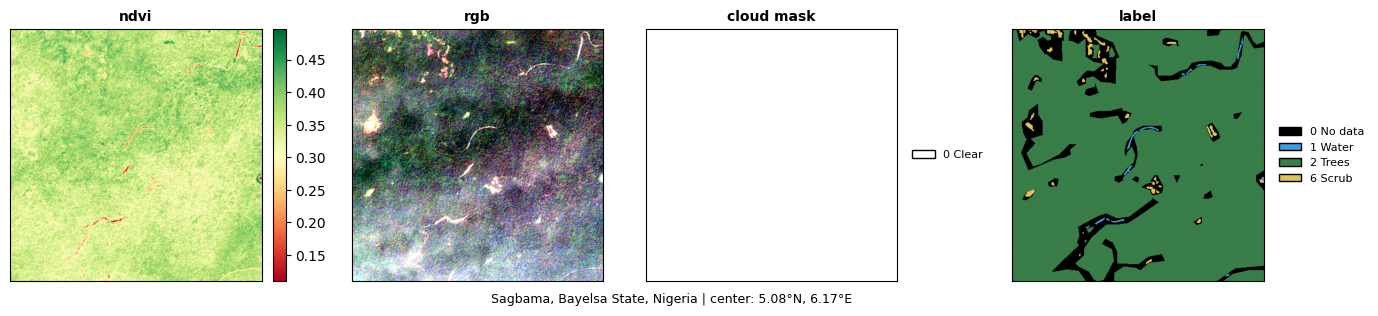

In [5]:
from geosave_engine.utils.geovis import plot_eda_grid, ContinuousLayer, RGBLayer, LabelLayer
import matplotlib.pyplot as plt

result = ingest(
    tiff_path = Path("../data/dw_6.1724033223_5.0839013693-20190108.tif")
)

layers = [
    ContinuousLayer("ndvi", result["ndvi"].squeeze()),
    RGBLayer("rgb", result["rgb"].squeeze()),
    LabelLayer("cloud mask", result["cloud_mask"].squeeze(), label_entries=mask_meta),
    LabelLayer("label", result["dynamicworld"].squeeze(), label_entries=label_meta),
]

fig, axes = plot_eda_grid(layers, cols=len(layers))
plt.show()

In [11]:
train_tif = list(Path("../data/dynamicworld_raw/train/").rglob("*.tif"))

for tiff_path in train_tif[:15]:
    source_id = tiff_path.stem
    if manifest.is_written(source_id):
        print(f"Skipping {source_id} (already ingested)")
        continue

    try:
        result = ingest(tiff_path)
        manifest.write_tile(result, split="train", source_id=source_id)
    except Exception as e:
        print(f"Error processing {source_id}: {e}")

Skipping dw_29.7936368307_-11.3916518808-20190912 (already ingested)
Skipping dw_117.7486418734_39.1123939392-20191027 (already ingested)
Skipping dw_35.4278672696_-18.2085019701-20190416 (already ingested)
Skipping dw_31.3131187484_30.1884357022-20190618 (already ingested)
Skipping dw_130.4813977160_49.5696937860-20191018 (already ingested)
Skipping dw_16.8028110902_-18.8065501639-20190805 (already ingested)
Skipping dw_70.4002398257_23.7475016205-20191013 (already ingested)
Skipping dw_31.3173158648_29.5409248758-20190618 (already ingested)
Skipping dw_22.7842092118_-19.0223871061-20190809 (already ingested)
Skipping dw_20.9551549891_-11.2747402038-20190815 (already ingested)
[########################################] | 100% Completed | 26.79 ss
[########################################] | 100% Completed | 63.77 ss
[########################################] | 100% Completed | 67.86 ss
[########################################] | 100% Completed | 26.10 ss
[############################